In [26]:
# External Imports
import sys
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torchinfo import summary
import matplotlib.pyplot as plt

# Internal Imports
sys.path.insert(0, '../src')
from src.DataIntegrity import data_integrity_check
from src.Dataset import split_patients, MriDataset, get_train_transforms, get_val_transforms, get_dataloaders
from src.Model import BaselineModel, fit

In [14]:
data_path = Path("../data/raw/lgg-mri-segmentation/kaggle_3m")
rejected_path = Path("../data/processed/data-integrity")

In [15]:
accepted_data, rejected_data = data_integrity_check(data_path)

[INFO] Data Integrity Checks: 100%|██████████| 112/112 [00:03<00:00, 34.07it/s]

[Info] Data Integrity Pipeline finished
[Info] Segments Accepted = 3929 | Segments Rejected = 0


In [16]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

[INFO]  Splitting dataset with seed 42...
[INFO]  Train Set: 76  | Tumor Ratio: 0.352
[INFO]  Valid Set: 17  | Tumor Ratio: 0.360
[INFO]  Test Set:  17  | Tumor Ratio: 0.372


In [17]:
BATCH_SIZE = 2
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_patients, val_patients, test_patients, batch_size=BATCH_SIZE)

In [24]:
baseline_model = BaselineModel()
device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_model.to(device)

BaselineModel(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Flatten(start_dim=1, end_dim=-1)
  (layer4): Sequential(
    (0): Linear(in_features=96800, out_features=256, bias=True)
    (1): ReLU()
  )
  (layer5): Linear(in_features=256, out_features=2, bias=True)
)

In [25]:
epoch_data = fit(
    model = baseline_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15
)

Epoch [1/15] Loss [Train | Validation]: 0.6297 | 0.6848 Accuracy: 0.7130 | 0.6616
Epoch [2/15] Loss [Train | Validation]: 0.5364 | 0.6503 Accuracy: 0.7446 | 0.6463
Epoch [3/15] Loss [Train | Validation]: 0.4810 | 0.6765 Accuracy: 0.7651 | 0.7266
Epoch [4/15] Loss [Train | Validation]: 0.4089 | 0.5489 Accuracy: 0.8222 | 0.7533
Epoch [5/15] Loss [Train | Validation]: 0.3689 | 0.6714 Accuracy: 0.8344 | 0.7725
Epoch [6/15] Loss [Train | Validation]: 0.3614 | 0.6516 Accuracy: 0.8513 | 0.7266
Epoch [7/15] Loss [Train | Validation]: 0.3536 | 0.6285 Accuracy: 0.8513 | 0.7859
Epoch [8/15] Loss [Train | Validation]: 0.3335 | 0.5480 Accuracy: 0.8567 | 0.8031
Epoch [9/15] Loss [Train | Validation]: 0.3192 | 0.5929 Accuracy: 0.8603 | 0.7973
Epoch [10/15] Loss [Train | Validation]: 0.3144 | 0.6310 Accuracy: 0.8732 | 0.7514
Epoch [11/15] Loss [Train | Validation]: 0.2995 | 0.8320 Accuracy: 0.8764 | 0.7629
Epoch [12/15] Loss [Train | Validation]: 0.3121 | 0.6382 Accuracy: 0.8693 | 0.8011
Epoch [13/15]

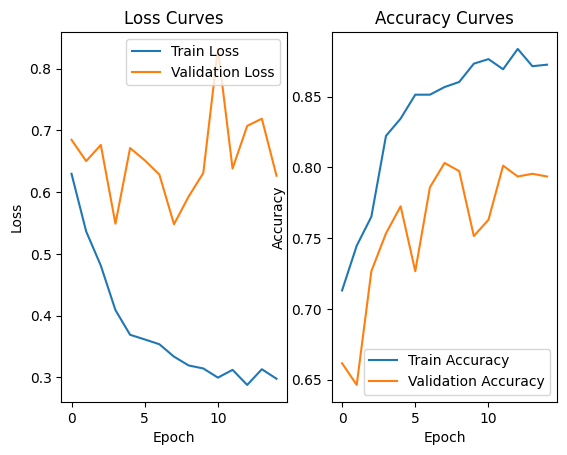

In [29]:
train_loss, val_loss, train_acc, val_acc = zip(*epoch_data.values())

# Display in matplotlib
fig, axs = plt.subplots(1, 2)

axs[0].plot(train_loss, label="Train Loss")
axs[0].plot(val_loss, label="Validation Loss")
axs[0].set_title("Loss Curves")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(train_acc, label="Train Accuracy")
axs[1].plot(val_acc, label="Validation Accuracy")
axs[1].set_title("Accuracy Curves")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
plt.show()